# Unit08 插值、微分與積分之運算 | Interpolation, Differentiation & Integration

本 Notebook 為 ChemE-3502「電腦在化工上之應用」課程 Unit08 的程式演練，
介紹如何使用 Python (NumPy + SciPy) 進行插值、數值微分與數值積分，
並透過化工實務案例展示各方法在工程問題上的應用。

## 學習目標
- 掌握 `scipy.interpolate` 中一維與二維插值方法 (`interp1d`, `CubicSpline`, `RegularGridInterpolator` 等)
- 理解數值微分的差分近似原理，並使用 `numpy.diff()` 與 `numpy.gradient()` 工具
- 熟悉數值積分方法 (`trapezoid`, `simpson`, `quad`, `dblquad`)，了解各方法適用情境
- 能夠針對化工物性數據進行插值估算，包含一維 (黏度-溫度) 與二維 (擴散係數-溫度-濃度)
- 透過數值微分由批次反應實驗數據推斷反應速率與反應動力學參數
- 應用數值積分解決追蹤劑 RTD 分析與填充塔 NTU 計算等化工積分問題

---
### 0. 環境設定

In [37]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Interpolation_Differentiation_Integration'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Interpolation_Differentiation_Integration
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Interpolation_Differentiation_Integration\figs


---
### 1. 載入套件

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 插值套件
from scipy.interpolate import (
    interp1d, CubicSpline,
    RegularGridInterpolator, RectBivariateSpline, griddata
)

# 積分套件
from scipy.integrate import trapezoid, simpson, fixed_quad, quad, dblquad, tplquad, nquad

# 最適化套件 (逆向插值用)
from scipy.optimize import brentq

# 統計套件
import scipy.stats as stats

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
import matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 2. 一維插值方法比較 (1D Interpolation Methods Comparison)

### 插值問題的基本概念

**插值 (Interpolation)** 是指在已知一組離散數據點 $(x_i, y_i)$ 的情況下，
估計在這些已知點之間任意位置的函數值。

**插值 vs 外插 (Extrapolation)**：
- **插值**：估計的點位於原始數據範圍 *內部* → 相對可靠
- **外插**：估計的點位於原始數據範圍 *之外* → 誤差風險極高

### `scipy.interpolate.interp1d` 方法說明

| `kind` 參數 | 說明 | 適用情境 |
|------------|------|---------|
| `'nearest'` | 最近鄰：取最近數據點的值 | 離散分類數據 |
| `'linear'` | 線性插值：兩點間直線連接 | 快速估算，精度適中 |
| `'quadratic'` | 二次多項式插值 | 平滑度要求較高 |
| `'cubic'` | 三次 Hermite 多項式插值 | 保持單調性，適合光滑數據 |

### `scipy.interpolate.CubicSpline` 說明

- **三次樣條插值**（C² 連續，預設採用 not-a-knot 邊界條件）：在每兩個相鄰數據點之間使用一個三次多項式，
  在所有數據點上保證函數值與一、二階導數的連續性
- 注意：與「自然三次樣條」不同，not-a-knot 條件不強制端點二階導數為零，曲線更自然
- 比 `interp1d(kind='cubic')` 更嚴格的平滑條件，結果更自然

### 範例：水蒸氣壓之插值

使用 5 個溫度-蒸氣壓測量數據點，比較四種插值方法在未測量溫度點的估算結果。

   溫度(°C)     Nearest      Linear       Cubic   CubicSpline
------------------------------------------------------------
       30       17.50       36.40       31.61         31.61
       60       92.50      180.00      148.28        148.28
       70      355.00      267.50      232.21        232.21
       90      355.00      557.50      527.36        527.36


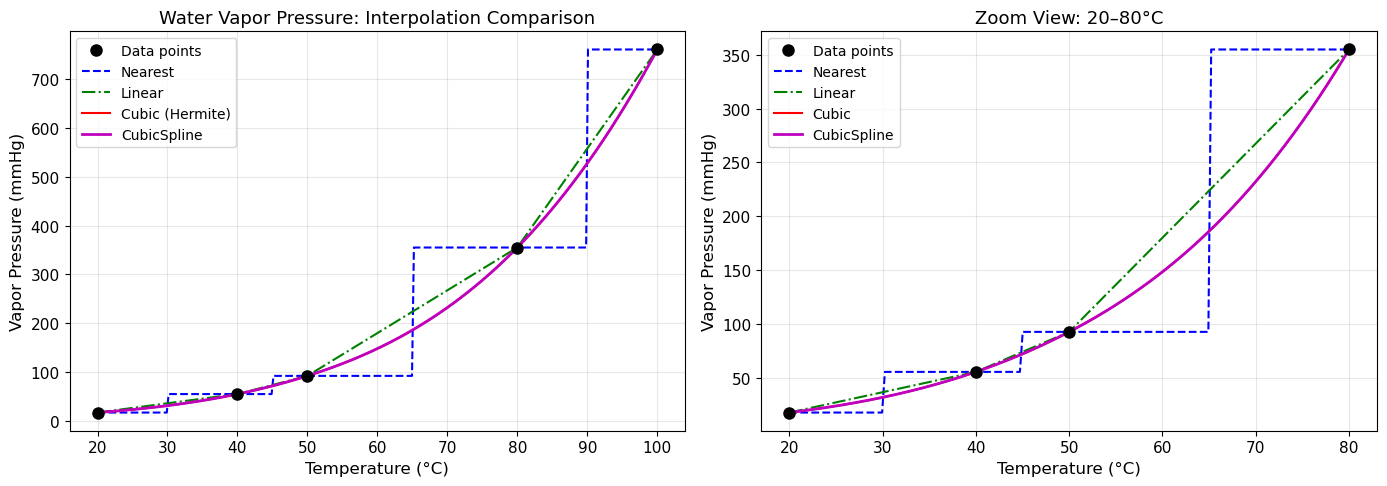


✓ 圖片已儲存


In [39]:
# ============================================================
# 範例：水蒸氣壓之一維插值比較
# ============================================================
# 已知實驗數據
T_data = np.array([20, 40, 50, 80, 100])       # 溫度 (°C)
P_data = np.array([17.5, 55.3, 92.5, 355.0, 760.0])  # 蒸氣壓 (mmHg)

# 欲插值的溫度點
T_interp = np.array([30, 60, 70, 90])

# ----- 建立各插值函數 -----
f_nearest   = interp1d(T_data, P_data, kind='nearest')
f_linear    = interp1d(T_data, P_data, kind='linear')
f_cubic     = interp1d(T_data, P_data, kind='cubic')
f_cspline   = CubicSpline(T_data, P_data)

# ----- 計算插值結果 -----
P_nearest   = f_nearest(T_interp)
P_linear    = f_linear(T_interp)
P_cubic     = f_cubic(T_interp)
P_cspline   = f_cspline(T_interp)

# ----- 數值結果表格 -----
print(f"{'溫度(°C)':>9}  {'Nearest':>10}  {'Linear':>10}  {'Cubic':>10}  {'CubicSpline':>12}")
print("-" * 60)
for i, T in enumerate(T_interp):
    print(f"{T:>9}  {P_nearest[i]:>10.2f}  {P_linear[i]:>10.2f}  {P_cubic[i]:>10.2f}  {P_cspline[i]:>12.2f}")

# ----- 繪圖比較 -----
T_fine = np.linspace(20, 100, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：整體比較
ax = axes[0]
ax.plot(T_data, P_data, 'ko', markersize=8, zorder=5, label='Data points')
ax.plot(T_fine, f_nearest(T_fine),  'b--',  lw=1.5, label='Nearest')
ax.plot(T_fine, f_linear(T_fine),   'g-.',  lw=1.5, label='Linear')
ax.plot(T_fine, f_cubic(T_fine),    'r-',   lw=1.5, label='Cubic (Hermite)')
ax.plot(T_fine, f_cspline(T_fine),  'm-',   lw=2.0, label='CubicSpline')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Vapor Pressure (mmHg)')
ax.set_title('Water Vapor Pressure: Interpolation Comparison')
ax.legend()

# 右圖：局部放大 (30–70°C)
ax2 = axes[1]
T_zoom = np.linspace(20, 80, 200)
ax2.plot(T_data[:4], P_data[:4], 'ko', markersize=8, zorder=5, label='Data points')
ax2.plot(T_zoom, f_nearest(T_zoom), 'b--',  lw=1.5, label='Nearest')
ax2.plot(T_zoom, f_linear(T_zoom),  'g-.',  lw=1.5, label='Linear')
ax2.plot(T_zoom, f_cubic(T_zoom),   'r-',   lw=1.5, label='Cubic')
ax2.plot(T_zoom, f_cspline(T_zoom), 'm-',   lw=2.0, label='CubicSpline')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Vapor Pressure (mmHg)')
ax2.set_title('Zoom View: 20–80°C')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec2_vapor_pressure_interp.png', bbox_inches='tight')
plt.show()
print("\n✓ 圖片已儲存")

---
## 3. 二維插值方法 (2D Interpolation Methods)

當函數依賴兩個獨立變數 $(x, y)$ 時，需要使用二維插值。

| 方法 | SciPy 函數 | 適用情境 |
|-----|-----------|---------|
| 規則網格插值 | `RegularGridInterpolator(points, values)` | 數據位於矩形規則網格上 |
| 散點插值 | `griddata(points, values, xi)` | 數據位置不規則（散點） |
| 二維樣條 | `RectBivariateSpline(x, y, z)` | 規則網格，需要連續偏導數 |

### 範例：合成的二維函數插值

使用 $f(T, C) = 2.5 \cdot e^{0.02(T-20)} \cdot e^{-1.5C}$ 模擬擴散係數隨溫度和濃度的雙變數物性數據。
已知稀疏量測點（規則網格 $5 \times 5$），插值求得完整曲面並比較三種方法的精度。

已知量測數據矩陣 (rows=Temp, cols=Conc):
[[2.1518 1.5941 1.1809 0.8748 0.6481]
 [2.9046 2.1518 1.5941 1.1809 0.8748]
 [3.9208 2.9046 2.1518 1.5941 1.1809]
 [5.2925 3.9208 2.9046 2.1518 1.5941]
 [7.1441 5.2925 3.9208 2.9046 2.1518]]


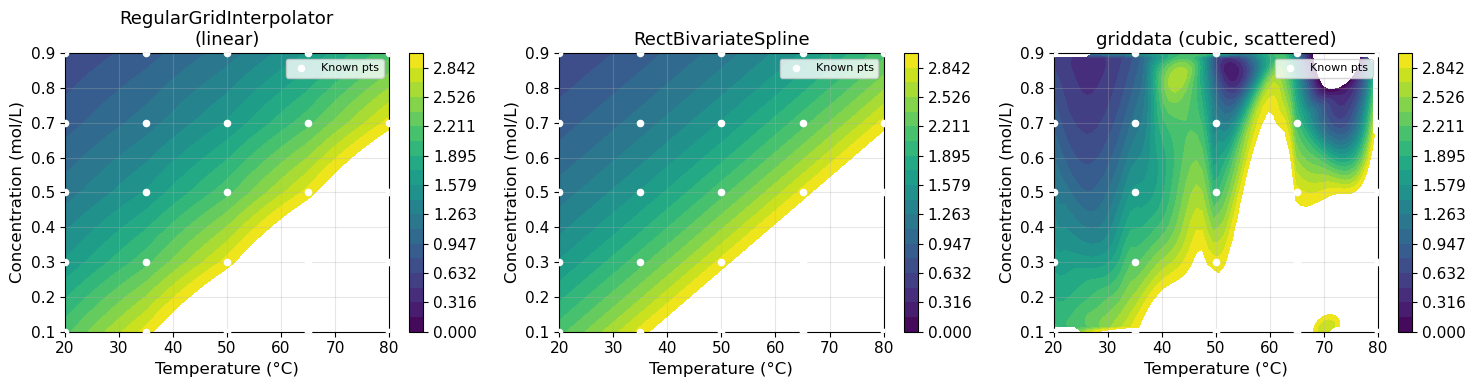

✓ 圖片已儲存

在 T=42.0°C, C=0.4 mol/L 的插值驗證:
  精確值:                  2.1304
  RegularGridInterpolator: 2.1787  (誤差: 2.27%)
  RectBivariateSpline:     2.1301  (誤差: 0.01%)


In [40]:
# ============================================================
# 範例：二維插值方法比較
# ============================================================
# 已知量測點 (規則網格，如：溫度 x 濃度)
T_pts  = np.array([20.0, 35.0, 50.0, 65.0, 80.0])   # 溫度 (°C)
C_pts  = np.array([0.1,  0.3,  0.5,  0.7,  0.9])    # 濃度 (mol/L)
TT, CC = np.meshgrid(T_pts, C_pts, indexing='ij')    # shape (5, 5)

# 已知函數（模擬擴散係數數據，單位 1e-9 m²/s）
Z_known = 2.5 * np.exp(0.02 * (TT - 20)) * np.exp(-1.5 * CC)

print("已知量測數據矩陣 (rows=Temp, cols=Conc):")
print(np.round(Z_known, 4))

# ----- 方法 1: RegularGridInterpolator -----
rgi = RegularGridInterpolator((T_pts, C_pts), Z_known, method='linear')

# ----- 方法 2: RectBivariateSpline -----
rbs = RectBivariateSpline(T_pts, C_pts, Z_known)

# ----- 高密度插值網格 -----
T_fine = np.linspace(20, 80, 60)
C_fine = np.linspace(0.1, 0.9, 60)
TT_f, CC_f = np.meshgrid(T_fine, C_fine, indexing='ij')

# RGI 需要 (N, 2) 形狀的查詢點
query_pts = np.column_stack([TT_f.ravel(), CC_f.ravel()])
Z_rgi = rgi(query_pts).reshape(TT_f.shape)
Z_rbs = rbs(T_fine, C_fine)

# ----- 散點插值示範 (griddata) -----
T_sc = TT.ravel() + np.random.RandomState(42).uniform(-2, 2, TT.size)
C_sc = CC.ravel() + np.random.RandomState(0).uniform(-0.02, 0.02, CC.size)
Z_sc = 2.5 * np.exp(0.02 * (T_sc - 20)) * np.exp(-1.5 * C_sc)
Z_grid = griddata((T_sc, C_sc), Z_sc, (TT_f, CC_f), method='cubic')

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
levels = np.linspace(0, 3.0, 20)

titles  = ['RegularGridInterpolator\n(linear)',
           'RectBivariateSpline',
           'griddata (cubic, scattered)']
Z_list  = [Z_rgi, Z_rbs, Z_grid]

for ax, Z_plot, title in zip(axes, Z_list, titles):
    cf = ax.contourf(T_fine, C_fine, Z_plot.T, levels=levels, cmap='viridis')
    ax.scatter(TT.ravel(), CC.ravel(), c='w', s=20, zorder=5, label='Known pts')
    plt.colorbar(cf, ax=ax)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Concentration (mol/L)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec3_2d_interp_comparison.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

# 某測試點插值驗證
T_test, C_test = 42.0, 0.4
exact = 2.5 * np.exp(0.02 * (T_test - 20)) * np.exp(-1.5 * C_test)
rgi_val = rgi([[T_test, C_test]])[0]
rbs_val = float(rbs(T_test, C_test))
print(f"\n在 T={T_test}°C, C={C_test} mol/L 的插值驗證:")
print(f"  精確值:                  {exact:.4f}")
print(f"  RegularGridInterpolator: {rgi_val:.4f}  (誤差: {abs(rgi_val-exact)/exact*100:.2f}%)")
print(f"  RectBivariateSpline:     {rbs_val:.4f}  (誤差: {abs(rbs_val-exact)/exact*100:.2f}%)")

---
## 4. 外插風險與邊界處理 (Extrapolation Risks & Boundary Handling)

`scipy.interpolate.interp1d` 在查詢超出數據範圍時的行為，由以下參數控制：

| 參數 | 值 | 行為 |
|-----|---|------|
| `bounds_error` | `True` (預設) | 超出範圍時拋出 `ValueError` |
| `bounds_error` | `False` | 允許超出範圍查詢 |
| `fill_value` | `np.nan` | 超出範圍填 NaN |
| `fill_value` | `'extrapolate'` | 用邊界多項式外插（風險高！） |
| `fill_value` | `(left_val, right_val)` | 左右端點分別填指定常數值 |

> **警告**：使用 `fill_value='extrapolate'` 進行外插時，誤差可能非常大，尤其是三次插值。

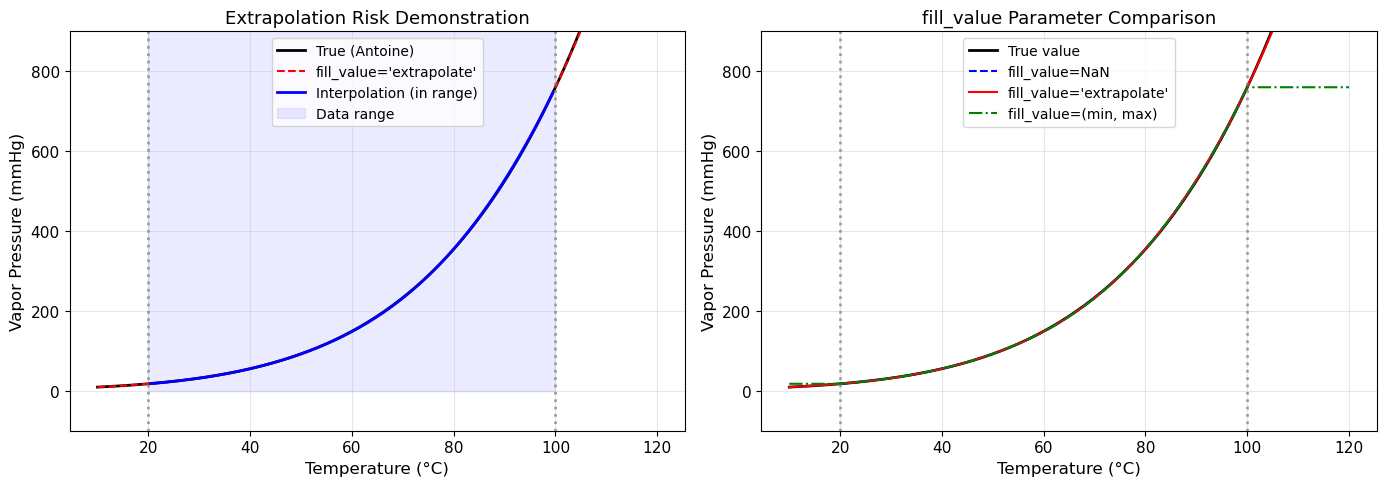

bounds_error=True 示範（查詢超出範圍的點）：
  捕獲到錯誤: A value (10.0) in x_new is below the interpolation range's minimum value (20).

✓ 圖片已儲存


In [41]:
# ============================================================
# 外插風險示範
# ============================================================
# 使用水蒸氣壓數據 (T_data, P_data 來自 Section 2)

# 真實值（Antoine 方程式近似）
def true_vapor_pressure(T):
    """Antoine equation approximation for water (mmHg)"""
    return 10 ** (8.07131 - 1730.63 / (233.426 + T))

T_query = np.linspace(10, 120, 200)  # 包含超出範圍的點

# 各種 fill_value 設定
f_error   = interp1d(T_data, P_data, kind='cubic', bounds_error=True)
f_nan     = interp1d(T_data, P_data, kind='cubic', bounds_error=False, fill_value=np.nan)
f_extrap  = interp1d(T_data, P_data, kind='cubic', bounds_error=False, fill_value='extrapolate')
f_clamp   = interp1d(T_data, P_data, kind='cubic', bounds_error=False, fill_value=(P_data[0], P_data[-1]))

# 計算插值結果 (對超出範圍的部分做處理)
mask_in  = (T_query >= T_data[0]) & (T_query <= T_data[-1])

P_true    = true_vapor_pressure(T_query)
P_nan     = f_nan(T_query)
P_extrap  = f_extrap(T_query)
P_clamp   = f_clamp(T_query)

# 繪圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_query, P_true, 'k-', lw=2, label='True (Antoine)')
ax.plot(T_query, P_extrap, 'r--', lw=1.5, label="fill_value='extrapolate'")
ax.plot(T_query[mask_in], P_extrap[mask_in], 'b-', lw=2, label='Interpolation (in range)')
ax.axvline(x=T_data[0],  color='gray', ls=':', alpha=0.7)
ax.axvline(x=T_data[-1], color='gray', ls=':', alpha=0.7)
ax.fill_betweenx([0, 900], T_data[0], T_data[-1], alpha=0.08, color='blue', label='Data range')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Vapor Pressure (mmHg)')
ax.set_title('Extrapolation Risk Demonstration')
ax.legend()
ax.set_ylim(-100, 900)

# 右圖：各種 fill_value 對比
ax2 = axes[1]
ax2.plot(T_query, P_true, 'k-', lw=2, label='True value')
ax2.plot(T_query, P_nan, 'b--', lw=1.5, label='fill_value=NaN')
ax2.plot(T_query, P_extrap, 'r-', lw=1.5, label="fill_value='extrapolate'")
ax2.plot(T_query, P_clamp, 'g-.', lw=1.5, label='fill_value=(min, max)')
ax2.axvline(x=T_data[0],  color='gray', ls=':', alpha=0.7)
ax2.axvline(x=T_data[-1], color='gray', ls=':', alpha=0.7)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Vapor Pressure (mmHg)')
ax2.set_title('fill_value Parameter Comparison')
ax2.legend()
ax2.set_ylim(-100, 900)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec4_extrapolation_risk.png', bbox_inches='tight')
plt.show()

# bounds_error=True 示範
print("bounds_error=True 示範（查詢超出範圍的點）：")
try:
    result = f_error(np.array([10.0, 50.0]))  # 10°C 超出範圍
except ValueError as e:
    print(f"  捕獲到錯誤: {e}")
print("\n✓ 圖片已儲存")

---
## 5. 數值微分：差分近似法 (Finite Difference Methods)

### 基本差分公式

設有等間距數據 $(x_i, y_i)$，步長 $h = x_{i+1} - x_i$，一階導數近似公式：

**前向差分 (Forward Difference)** — 誤差 $O(h)$：

$$y'_i \approx \frac{y_{i+1} - y_i}{\Delta x}$$

**後向差分 (Backward Difference)** — 誤差 $O(h)$：

$$y'_i \approx \frac{y_i - y_{i-1}}{\Delta x}$$

**中間差分 (Central Difference)** — 誤差 $O(h^2)$，精度最佳：

$$y'_i \approx \frac{y_{i+1} - y_{i-1}}{2\Delta x}$$

> 中間差分的對稱性可抵消正負誤差，精度為 $O(h^2)$，比前後向差分高一個數量級。

### 截斷誤差 vs 步長 $h$ 的關係
- 步長 $h$ 越小，截斷誤差越小（精度越高）
- 但步長太小會導致浮點運算的捨入誤差增大
- 實際應用中存在最佳步長（通常約 $10^{-5}$ 至 $10^{-8}$）

步長 h = 0.1282

平均絕對誤差比較:
  前向差分: 0.040041
  後向差分: 0.040041
  中間差分: 0.001763  ← 最佳


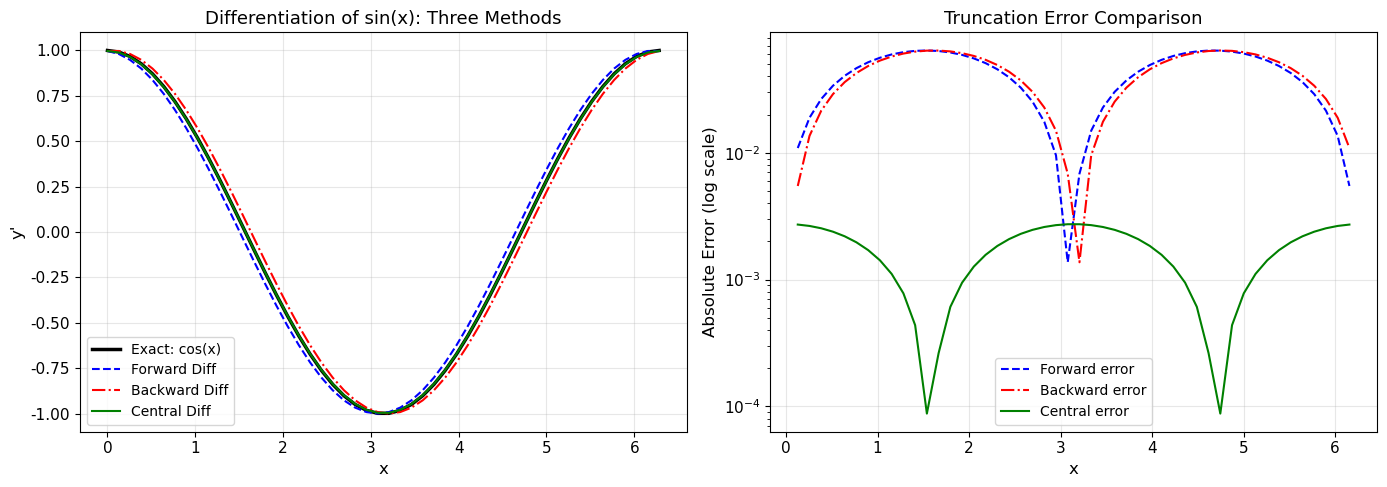

✓ 圖片已儲存


In [42]:
# ============================================================
# 示範：手動實作三種差分公式，與解析導數比較
# ============================================================
# 測試函數 f(x) = sin(x)，解析導數 f'(x) = cos(x)
x = np.linspace(0, 2 * np.pi, 50)
h = x[1] - x[0]
y = np.sin(x)
dy_exact = np.cos(x)

# ----- 三種差分公式 -----
n = len(x)

# 前向差分 (最後一點用後向差分補齊)
dy_forward = np.zeros(n)
dy_forward[:-1] = (y[1:] - y[:-1]) / h
dy_forward[-1]  = (y[-1] - y[-2]) / h

# 後向差分 (第一點用前向差分補齊)
dy_backward = np.zeros(n)
dy_backward[1:] = (y[1:] - y[:-1]) / h
dy_backward[0]  = (y[1] - y[0]) / h

# 中間差分 (邊界點用前/後向差分)
dy_central = np.zeros(n)
dy_central[1:-1] = (y[2:] - y[:-2]) / (2 * h)
dy_central[0]    = (y[1] - y[0]) / h
dy_central[-1]   = (y[-1] - y[-2]) / h

# ----- 誤差計算 -----
err_fwd  = np.abs(dy_forward  - dy_exact)
err_bwd  = np.abs(dy_backward - dy_exact)
err_ctr  = np.abs(dy_central  - dy_exact)

print(f"步長 h = {h:.4f}")
print(f"\n平均絕對誤差比較:")
print(f"  前向差分: {err_fwd.mean():.6f}")
print(f"  後向差分: {err_bwd.mean():.6f}")
print(f"  中間差分: {err_ctr.mean():.6f}  ← 最佳")

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x, dy_exact,    'k-',  lw=2.5, label='Exact: cos(x)')
ax.plot(x, dy_forward,  'b--', lw=1.5, label='Forward Diff')
ax.plot(x, dy_backward, 'r-.',  lw=1.5, label='Backward Diff')
ax.plot(x, dy_central,  'g-',  lw=1.5, label='Central Diff')
ax.set_xlabel('x')
ax.set_ylabel("y'")
ax.set_title('Differentiation of sin(x): Three Methods')
ax.legend()

ax2 = axes[1]
ax2.semilogy(x[1:-1], err_fwd[1:-1],  'b--', lw=1.5, label='Forward error')
ax2.semilogy(x[1:-1], err_bwd[1:-1],  'r-.', lw=1.5, label='Backward error')
ax2.semilogy(x[1:-1], err_ctr[1:-1],  'g-',  lw=1.5, label='Central error')
ax2.set_xlabel('x')
ax2.set_ylabel('Absolute Error (log scale)')
ax2.set_title('Truncation Error Comparison')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec5_finite_difference.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 6. NumPy 數值微分工具 (NumPy Differentiation Tools)

### 主要工具說明

| 函數 | 說明 | 輸出形狀 |
|-----|------|---------|
| `numpy.diff(y)` | 計算相鄰元素差分 $y_{i+1} - y_i$，**輸出比輸入少 1 個元素** | `(N-1,)` |
| `numpy.diff(y, n=2)` | n 階差分 | `(N-n,)` |
| `numpy.gradient(y, x)` | 中間差分，**邊界自動用前後向差分**，輸出長度與輸入相同 | `(N,)` |
| `numpy.gradient(y, dx)` | 等間距數據使用步長 `dx` | `(N,)` |

### `numpy.diff` vs `numpy.gradient` 比較

```python
diff(y)         # → [y[1]-y[0], y[2]-y[1], ..., y[N-1]-y[N-2]]  長度 N-1
gradient(y, x)  # → 中間差分，長度 N，邊界點用 forward/backward
```

### 步長對截斷誤差的影響

截斷誤差隨步長 $h$ 線性減小（中間差分為 $h^2$），但步長過小會引入數值捨入誤差。

差分法比較 (dP/dQ):

 numpy.diff  (長度=7):
  x_mid=  5.40 cm/s  →  dP/dQ = 0.02769 kPa·s/cm
  x_mid= 13.42 cm/s  →  dP/dQ = 0.05296 kPa·s/cm
  x_mid= 19.47 cm/s  →  dP/dQ = 0.06686 kPa·s/cm
  x_mid= 27.73 cm/s  →  dP/dQ = 0.07720 kPa·s/cm
  x_mid= 34.66 cm/s  →  dP/dQ = 0.15500 kPa·s/cm
  x_mid= 38.32 cm/s  →  dP/dQ = 0.13269 kPa·s/cm
  x_mid= 41.78 cm/s  →  dP/dQ = 0.12053 kPa·s/cm

 numpy.gradient (長度=8):
  x=  0.00 cm/s  →  dP/dQ = 0.02769 kPa·s/cm
  x= 10.80 cm/s  →  dP/dQ = 0.04472 kPa·s/cm
  x= 16.03 cm/s  →  dP/dQ = 0.05897 kPa·s/cm
  x= 22.91 cm/s  →  dP/dQ = 0.07116 kPa·s/cm
  x= 32.56 cm/s  →  dP/dQ = 0.13141 kPa·s/cm
  x= 36.76 cm/s  →  dP/dQ = 0.14220 kPa·s/cm
  x= 39.88 cm/s  →  dP/dQ = 0.12721 kPa·s/cm
  x= 43.68 cm/s  →  dP/dQ = 0.12053 kPa·s/cm


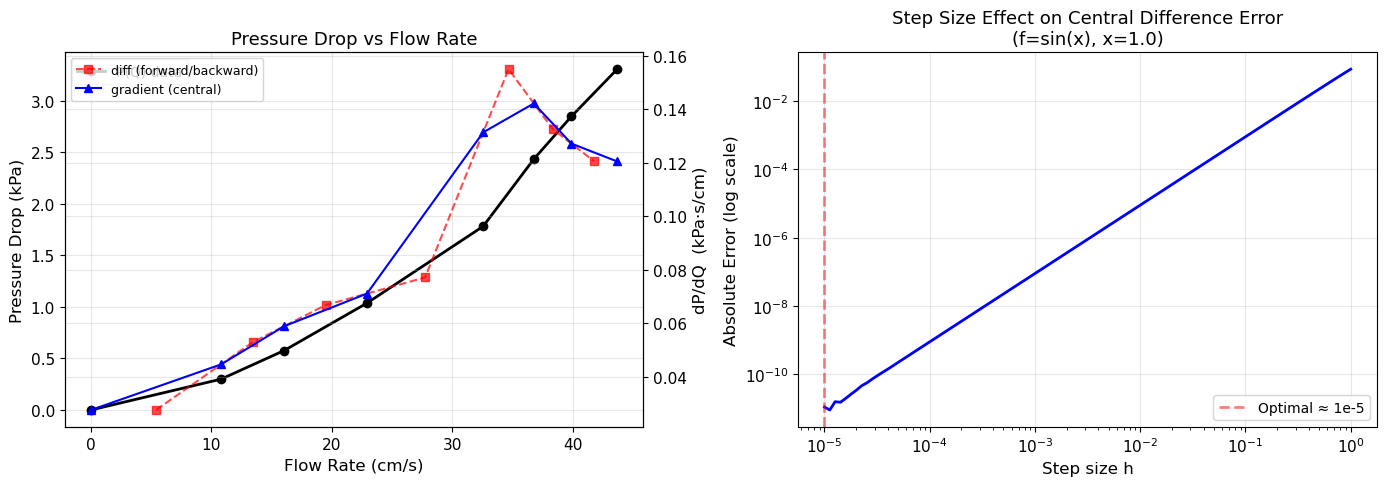

✓ 圖片已儲存


In [43]:
# ============================================================
# numpy.diff 與 numpy.gradient 示範
# ============================================================
# 流率與壓降數據 (Table 3.1 in MATLAB textbook)
x_flow = np.array([0, 10.80, 16.03, 22.91, 32.56, 36.76, 39.88, 43.68])   # 流率 (cm/s)
y_press = np.array([0, 0.299, 0.576, 1.036, 1.781, 2.432, 2.846, 3.304])  # 壓降 (kPa)

n = len(x_flow)

# 方法 1: numpy.diff — 前後向差分 dP/dQ
d_diff = np.diff(y_press) / np.diff(x_flow)          # 長度 N-1
x_mid  = (x_flow[1:] + x_flow[:-1]) / 2              # 中間點位置

# 方法 2: numpy.gradient — 中間差分（輸出長度 = 輸入長度）
d_grad = np.gradient(y_press, x_flow)                 # 長度 N

print("差分法比較 (dP/dQ):")
print(f"\n numpy.diff  (長度={len(d_diff)}):")
for xi, di in zip(x_mid, d_diff):
    print(f"  x_mid={xi:6.2f} cm/s  →  dP/dQ = {di:.5f} kPa·s/cm")

print(f"\n numpy.gradient (長度={len(d_grad)}):")
for xi, di in zip(x_flow, d_grad):
    print(f"  x={xi:6.2f} cm/s  →  dP/dQ = {di:.5f} kPa·s/cm")

# ----- 步長對截斷誤差的影響 -----
h_values = np.logspace(-5, 0, 100)
x0 = 1.0
exact_deriv = np.cos(x0)  # f(x)=sin(x), f'(x)=cos(x)

errors = []
for h in h_values:
    approx = (np.sin(x0 + h) - np.sin(x0 - h)) / (2 * h)
    errors.append(abs(approx - exact_deriv))

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_flow, y_press, 'ko-', lw=2, label='P(Q) data')
ax.set_xlabel('Flow Rate (cm/s)')
ax.set_ylabel('Pressure Drop (kPa)')
ax.set_title('Pressure Drop vs Flow Rate')
ax.legend()
ax2_twin = ax.twinx()
ax2_twin.plot(x_mid,  d_diff, 'rs--', lw=1.5, label='diff (forward/backward)', alpha=0.7)
ax2_twin.plot(x_flow, d_grad, 'b^-',  lw=1.5, label='gradient (central)')
ax2_twin.set_ylabel("dP/dQ  (kPa·s/cm)")
ax2_twin.legend(loc='upper left', fontsize=9)

ax3 = axes[1]
ax3.loglog(h_values, errors, 'b-', lw=2)
ax3.set_xlabel('Step size h')
ax3.set_ylabel('Absolute Error (log scale)')
ax3.set_title('Step Size Effect on Central Difference Error\n(f=sin(x), x=1.0)')
ax3.axvline(x=1e-5, color='r', ls='--', alpha=0.5, label='Optimal ≈ 1e-5')
ax3.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec6_numpy_diff_gradient.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 7. 高階微分與偏微分 (Higher-Order & Partial Derivatives)

### 二階中間差分公式

$$y''_i \approx \frac{y_{i+1} - 2y_i + y_{i-1}}{\Delta x^2}$$

### 二階微分的計算方式
- **方法 1**：直接套公式（上式）
- **方法 2**：對 `numpy.gradient` 結果再次呼叫 `numpy.gradient`

### 偏微分（多變數函數）

對於 $f(x, y)$ 的偏微分：

$$\frac{\partial f}{\partial x}\bigg|_{y=y_j} \approx \frac{f_{i+1,j} - f_{i-1,j}}{2\Delta x}$$

在 NumPy 中，對二維數組使用 `numpy.gradient(Z, x, y)` 可同時計算兩個方向的偏微分。

二階微分誤差比較 (f=sin, f''=-sin):
  直接公式:        平均絕對誤差 = 0.000216
  兩次 gradient:   平均絕對誤差 = 0.000863

偏微分誤差 (f = x²y + sin(y)):
  ∂f/∂x 平均絕對誤差: 0.002564
  ∂f/∂y 平均絕對誤差: 0.000824


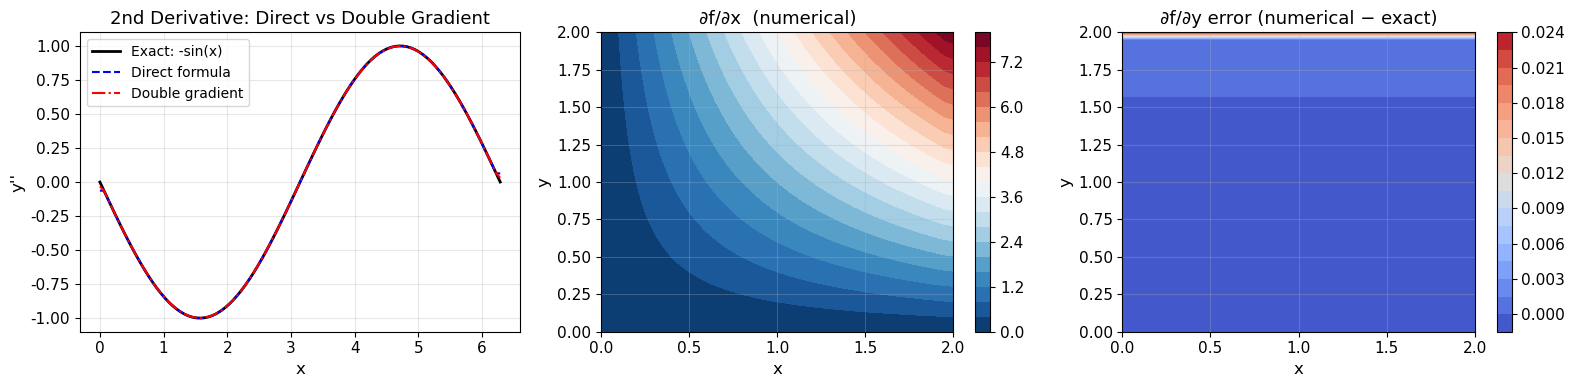

✓ 圖片已儲存


In [44]:
# ============================================================
# 高階微分與偏微分示範
# ============================================================

# --- 二階微分 ---
x = np.linspace(0, 2 * np.pi, 100)
h = x[1] - x[0]
y = np.sin(x)               # f(x) = sin(x)
dy2_exact  = -np.sin(x)     # f''(x) = -sin(x)

# 方法 1: 直接公式
dy2_direct    = np.zeros_like(y)
dy2_direct[1:-1] = (y[2:] - 2*y[1:-1] + y[:-2]) / h**2
dy2_direct[0]    = dy2_direct[1]    # 邊界點補外推
dy2_direct[-1]   = dy2_direct[-2]

# 方法 2: 兩次 gradient
dy1_grad  = np.gradient(y, x)
dy2_grad  = np.gradient(dy1_grad, x)

print("二階微分誤差比較 (f=sin, f''=-sin):")
err1 = np.abs(dy2_direct[1:-1] - dy2_exact[1:-1]).mean()
err2 = np.abs(dy2_grad[1:-1]   - dy2_exact[1:-1]).mean()
print(f"  直接公式:        平均絕對誤差 = {err1:.6f}")
print(f"  兩次 gradient:   平均絕對誤差 = {err2:.6f}")

# --- 偏微分 ---
x2 = np.linspace(0, 2, 40)
y2 = np.linspace(0, 2, 40)
XX, YY = np.meshgrid(x2, y2, indexing='ij')

# f(x, y) = x^2 * y + sin(y)
# ∂f/∂x = 2xy,   ∂f/∂y = x^2 + cos(y)
Z2 = XX**2 * YY + np.sin(YY)
dZ_dx_exact = 2 * XX * YY
dZ_dy_exact = XX**2 + np.cos(YY)

# numpy.gradient 返回 [∂Z/∂x, ∂Z/∂y] (按 axis 0, 1 分別)
dZ_dx_num, dZ_dy_num = np.gradient(Z2, x2, y2)

err_dx = np.abs(dZ_dx_num - dZ_dx_exact).mean()
err_dy = np.abs(dZ_dy_num - dZ_dy_exact).mean()
print(f"\n偏微分誤差 (f = x²y + sin(y)):")
print(f"  ∂f/∂x 平均絕對誤差: {err_dx:.6f}")
print(f"  ∂f/∂y 平均絕對誤差: {err_dy:.6f}")

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(x, dy2_exact,  'k-',  lw=2,   label="Exact: -sin(x)")
ax.plot(x, dy2_direct, 'b--', lw=1.5, label="Direct formula")
ax.plot(x, dy2_grad,   'r-.',  lw=1.5, label="Double gradient")
ax.set_title("2nd Derivative: Direct vs Double Gradient")
ax.set_xlabel('x')
ax.set_ylabel("y''")
ax.legend()

ax2 = axes[1]
cf1 = ax2.contourf(x2, y2, dZ_dx_num.T, cmap='RdBu_r', levels=20)
plt.colorbar(cf1, ax=ax2)
ax2.set_title("∂f/∂x  (numerical)")
ax2.set_xlabel('x'); ax2.set_ylabel('y')

ax3 = axes[2]
cf2 = ax3.contourf(x2, y2, (dZ_dy_num - dZ_dy_exact).T, cmap='coolwarm', levels=20)
plt.colorbar(cf2, ax=ax3)
ax3.set_title("∂f/∂y error (numerical − exact)")
ax3.set_xlabel('x'); ax3.set_ylabel('y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec7_higher_order_partial.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 8. 數值積分：離散數據積分 (Numerical Integration: Basic Rules)

### 主要方法

| 方法 | SciPy 函數 | 特點 |
|-----|-----------|------|
| 梯形法 | `scipy.integrate.trapezoid(y, x)` | 簡單，支援非等間距 |
| Simpson 法 | `scipy.integrate.simpson(y, x)` | 比梯形法精確，需偶數子區間 |
| Gauss 積分 | `scipy.integrate.fixed_quad(f, a, b, n=5)` | 對函數積分，精度高 |

### 誤差階數

- **梯形法**：誤差 $O(h^2)$，即步長縮小 10 倍，誤差縮小 100 倍
- **Simpson 法**：誤差 $O(h^4)$，精度更高

### 適用情境
- 已知離散數據 $(x_i, y_i)$：使用 `trapezoid` 或 `simpson`
- 已知解析函數 $f(x)$：使用 `quad` (Section 9)

精確值: 2.0

    N     trapezoid       simpson      err_trap      err_simp
------------------------------------------------------------
    5    1.89611890    2.00455975      1.04e-01      4.56e-03
   11    1.98352354    2.00010952      1.65e-02      1.10e-04
   21    1.99588597    2.00000678      4.11e-03      6.78e-06
   51    1.99934198    2.00000017      6.58e-04      1.73e-07
  101    1.99983550    2.00000001      1.64e-04      1.08e-08

Gauss 積分 (fixed_quad):
  n= 3: 2.0013889136  誤差: 1.39e-03
  n= 5: 2.0000001103  誤差: 1.10e-07
  n=10: 2.0000000000  誤差: 2.66e-15
  n=20: 2.0000000000  誤差: 2.66e-15

非等間距數據積分示範:
  非等間距梯形法 (N=10): 1.941302  誤差: 5.87e-02


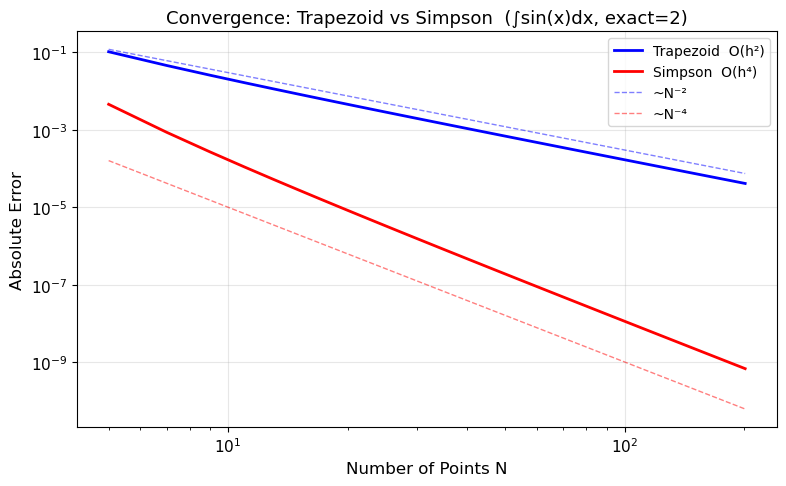

✓ 圖片已儲存


In [45]:
# ============================================================
# 數值積分方法比較：梯形法 vs Simpson法 vs Gauss積分
# ============================================================
# 測試積分：∫₀^π sin(x) dx = 2 (精確值)
exact_val = 2.0
a, b = 0.0, np.pi

results = {}

# ----- 不同數據點數測試 -----
N_list = [5, 11, 21, 51, 101]

print(f"精確值: {exact_val}")
print(f"\n{'N':>5}  {'trapezoid':>12}  {'simpson':>12}  {'err_trap':>12}  {'err_simp':>12}")
print("-" * 60)

for N in N_list:
    x_pts = np.linspace(a, b, N)
    y_pts = np.sin(x_pts)
    res_trap = trapezoid(y_pts, x_pts)
    res_simp = simpson(y_pts, x_pts)
    print(f"{N:>5}  {res_trap:>12.8f}  {res_simp:>12.8f}  {abs(res_trap-exact_val):>12.2e}  {abs(res_simp-exact_val):>12.2e}")
    results[N] = {'trap': res_trap, 'simp': res_simp}

# ----- Gauss 積分示範 -----
print("\nGauss 積分 (fixed_quad):")
for n_pts in [3, 5, 10, 20]:
    res_gauss, _ = fixed_quad(np.sin, a, b, n=n_pts)
    print(f"  n={n_pts:2d}: {res_gauss:.10f}  誤差: {abs(res_gauss-exact_val):.2e}")

# ----- 非等間距數據積分示範 -----
print("\n非等間距數據積分示範:")
x_nonunif = np.sort(np.concatenate([[0, np.pi], np.random.RandomState(42).uniform(0, np.pi, 8)]))
y_nonunif = np.sin(x_nonunif)
res_trap_nu = trapezoid(y_nonunif, x_nonunif)
print(f"  非等間距梯形法 (N={len(x_nonunif)}): {res_trap_nu:.6f}  誤差: {abs(res_trap_nu-exact_val):.2e}")

# ----- 誤差 vs N 繪圖 -----
N_arr = np.arange(5, 202, 2)
err_trap_arr = []
err_simp_arr = []
for N in N_arr:
    xp = np.linspace(a, b, N)
    yp = np.sin(xp)
    err_trap_arr.append(abs(trapezoid(yp, xp) - exact_val))
    err_simp_arr.append(abs(simpson(yp, xp) - exact_val))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_arr, err_trap_arr, 'b-', lw=2, label='Trapezoid  O(h²)')
ax.loglog(N_arr, err_simp_arr, 'r-', lw=2, label="Simpson  O(h⁴)")
# Reference slopes
ax.loglog(N_arr, 3 / N_arr**2, 'b--', lw=1, alpha=0.5, label='~N⁻²')
ax.loglog(N_arr, 0.1 / N_arr**4, 'r--', lw=1, alpha=0.5, label='~N⁻⁴')
ax.set_xlabel('Number of Points N')
ax.set_ylabel('Absolute Error')
ax.set_title('Convergence: Trapezoid vs Simpson  (∫sin(x)dx, exact=2)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'sec8_integration_convergence.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 9. SciPy 函數積分工具 (`scipy.integrate.quad`)

`scipy.integrate.quad(func, a, b)` 使用自適應 Gauss-Kronrod 積分法計算 $\int_a^b f(x)\,dx$。

### 主要用法

```python
result, error = quad(func, a, b)
result, error = quad(func, a, b, args=(param1, param2))   # 帶參數
result, error = quad(func, 0, np.inf)                      # 廣義積分
result, error = quad(func, a, b, epsabs=1e-10, epsrel=1e-10)  # 精度設定
```

### 回傳值說明
- `result`: 積分估計值
- `error`: 絕對誤差估計（通常遠小於精確誤差上界）

### 廣義積分支援
`quad` 允許積分上限或下限為 `np.inf` 或 `-np.inf`，如：
$\int_0^{\infty} e^{-x} \, dx = 1$

基本積分  ∫₀^π sin(x)dx = 2.0000000000  (精確: 2.0)  誤差估計: 2.22e-14
廣義積分  ∫_(-∞)^(∞) e^(-x²)dx = 1.7724538509  (精確: √π=1.7724538509)
  ∫₀^π sin(1x)dx = 2.000000
  ∫₀^π sin(2x)dx = 0.000000
  ∫₀^π sin(3x)dx = 0.666667

廣義積分  ∫₀^∞ e^(-x)dx = 1.0000000000  (精確: 1.0)

精度設定比較 (∫₀^π sin(x)dx):
  epsabs=1e-04: result=2.000000000000  err_estimate=2.22e-14
  epsabs=1e-08: result=2.000000000000  err_estimate=2.22e-14
  epsabs=1e-12: result=2.000000000000  err_estimate=2.22e-14


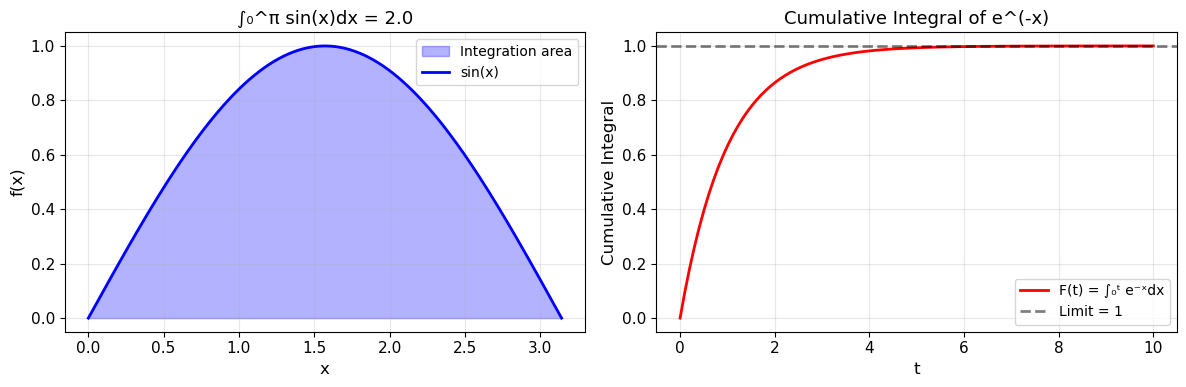

✓ 圖片已儲存


In [46]:
# ============================================================
# scipy.integrate.quad 各種用法示範
# ============================================================

# --- 1. 基本用法 ---
result1, err1 = quad(np.sin, 0, np.pi)
print(f"基本積分  ∫₀^π sin(x)dx = {result1:.10f}  (精確: 2.0)  誤差估計: {err1:.2e}")

# --- 2. lambda 函數 ---
result2, err2 = quad(lambda x: np.exp(-x**2), -np.inf, np.inf)
print(f"廣義積分  ∫_(-∞)^(∞) e^(-x²)dx = {result2:.10f}  (精確: √π={np.sqrt(np.pi):.10f})")

# --- 3. 帶參數的函數 ---
def integrand_with_param(x, k):
    """f(x, k) = sin(k*x)"""
    return np.sin(k * x)

for k in [1, 2, 3]:
    res, _ = quad(integrand_with_param, 0, np.pi, args=(k,))
    print(f"  ∫₀^π sin({k}x)dx = {res:.6f}")

# --- 4. 廣義積分（半無限） ---
result4, err4 = quad(lambda x: np.exp(-x), 0, np.inf)
print(f"\n廣義積分  ∫₀^∞ e^(-x)dx = {result4:.10f}  (精確: 1.0)")

# --- 5. 精度設定示範 ---
print("\n精度設定比較 (∫₀^π sin(x)dx):")
for epsabs in [1e-4, 1e-8, 1e-12]:
    res, err = quad(np.sin, 0, np.pi, epsabs=epsabs, epsrel=epsabs)
    print(f"  epsabs={epsabs:.0e}: result={res:.12f}  err_estimate={err:.2e}")

# --- 6. 積分結果視覺化 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖：被積分函數與積分面積
x_plot = np.linspace(0, np.pi, 200)
ax = axes[0]
ax.fill_between(x_plot, np.sin(x_plot), alpha=0.3, color='blue', label='Integration area')
ax.plot(x_plot, np.sin(x_plot), 'b-', lw=2, label='sin(x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('∫₀^π sin(x)dx = 2.0')
ax.legend()

# 右圖：∫₀^t e^(-x)dx vs t (累積積分)
t_vals = np.linspace(0, 10, 100)
cum_int = [quad(lambda x: np.exp(-x), 0, t)[0] for t in t_vals]
ax2 = axes[1]
ax2.plot(t_vals, cum_int, 'r-', lw=2, label='F(t) = ∫₀ᵗ e⁻ˣdx')
ax2.axhline(y=1.0, color='k', ls='--', alpha=0.5, label='Limit = 1')
ax2.set_xlabel('t')
ax2.set_ylabel('Cumulative Integral')
ax2.set_title('Cumulative Integral of e^(-x)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec9_quad_demo.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 10. 多維積分 (Multi-Dimensional Integration)

| 函數 | 用途 | 語法 |
|-----|------|------|
| `dblquad(f, a, b, gfun, hfun)` | 二重積分 $\int_a^b \int_{g(x)}^{h(x)} f(y,x)\,dy\,dx$ | `gfun`, `hfun` 可為常數或函數 |
| `tplquad(f, a, b, gfun, hfun, qfun, rfun)` | 三重積分 | 三層積分限 |
| `nquad(f, ranges)` | N 維積分，積分限為列表 | `ranges = [(a1,b1), (a2,b2), ...]` |

> **注意**：`dblquad(f, a, b, gfun, hfun)` 中，被積分函數的變數順序是 **`f(y, x)`**（內層變數在前）。

In [47]:
from scipy.integrate import dblquad, tplquad, nquad

# --- 1. dblquad: 二重積分 ---
# ∫₀¹ ∫₀¹ (x²+y²) dy dx = 2/3
def f2D_a(y, x):   # y 是內層積分變數（第一引數）
    return x**2 + y**2

result_dbl, _ = dblquad(f2D_a, 0, 1, 0, 1)
print(f"dblquad: ∫₀¹∫₀¹ (x²+y²) dydx = {result_dbl:.8f}  (精確: 2/3 = {2/3:.8f})")

# ∫₀¹ ∫₀ˣ (x+y) dy dx = 0.5
def f2D_b(y, x):
    return x + y

result_dbl2, _ = dblquad(f2D_b, 0, 1, 0, lambda x: x)
print(f"dblquad (variable limit): ∫₀¹ ∫₀ˣ (x+y) dydx = {result_dbl2:.8f}  (精確: 0.5)")

# --- 3. tplquad: 三重積分 ---
# ∫₀¹ ∫₀¹ ∫₀¹ xyz dz dy dx = 1/8 = 0.125
def f3D(z, y, x):  # z 最內層
    return x * y * z

result_tpl, _ = tplquad(f3D, 0, 1, 0, 1, 0, 1)
print(f"tplquad: ∫₀¹∫₀¹∫₀¹ xyz dzdydx = {result_tpl:.8f}  (精確: 1/8 = {1/8:.8f})")

# --- 4. nquad: N 維積分 ---
def f4D(x4, x3, x2, x1):  # 最內層在前
    return x1 * x2 * x3 * x4

result_n, _ = nquad(f4D, [[0, 1], [0, 1], [0, 1], [0, 1]])
print(f"nquad (4D): ∫ x₁x₂x₃x₄ = {result_n:.8f}  (精確: 1/16 = {1/16:.8f})")

# --- 化工應用示範：球體體積 ---
# V = ∫₀^(2π) dφ ∫₀^π sinθ dθ ∫₀^R r² dr = 4/3 π R³
# 注意：nquad(f, ranges) 中，f 的第 i 個引數對應 ranges[i]
# 函數參數順序必須與 ranges 清單順序一致
R = 1.0
def sphere_integrand(phi, theta, r):  # 引數順序與 ranges 一致
    return r**2 * np.sin(theta)

V_sphere, _ = nquad(
    sphere_integrand,
    [[0, 2*np.pi],    # ranges[0] → phi（第一引數）
     [0, np.pi],      # ranges[1] → theta（第二引數）
     [0, R]]          # ranges[2] → r（第三引數）
)
exact_vol = 4/3 * np.pi * R**3
print(f"\n球體體積 (R=1): nquad = {V_sphere:.8f}  (精確: {exact_vol:.8f})")

dblquad: ∫₀¹∫₀¹ (x²+y²) dydx = 0.66666667  (精確: 2/3 = 0.66666667)
dblquad (variable limit): ∫₀¹ ∫₀ˣ (x+y) dydx = 0.50000000  (精確: 0.5)
tplquad: ∫₀¹∫₀¹∫₀¹ xyz dzdydx = 0.12500000  (精確: 1/8 = 0.12500000)
nquad (4D): ∫ x₁x₂x₃x₄ = 0.06250000  (精確: 1/16 = 0.06250000)

球體體積 (R=1): nquad = 4.18879020  (精確: 4.18879020)


---
## 11. 化工應用一：物性數據插值 (Physical Property Interpolation)

### 問題描述

化工製程設計中，常需要物性數據（如黏度、熱容量、密度）在不同操作溫度下的值，
但實驗量測往往只在有限溫度下進行。透過插值法，可以估算中間溫度點的物性值。

### 逆向插值 (Inverse Interpolation)

若已知目標物性值 $y^*$，求對應的操作溫度 $T^*$，即求 $f(T^*) = y^*$。

作法：使用 `scipy.optimize.brentq()` 在插值函數上求根：

```python
f_cs = CubicSpline(T_data, mu_data)
T_star = brentq(lambda T: f_cs(T) - mu_target, T_min, T_max)
```

插值結果比較:
   T(°C)    Linear     Cubic   CubicSpline
    50.0    0.4305    0.4266        0.4266
    70.0    0.3600    0.3580        0.3580

逆向插值: 目標黏度 0.4 mPa·s 對應溫度 T* = 57.11 °C
  驗證: f_cs(57.11) = 0.400000 mPa·s

Andrade 方程式擬合: ln(μ) = 990.9/T + -3.912
  (A = -3.912, B = 990.9 K)


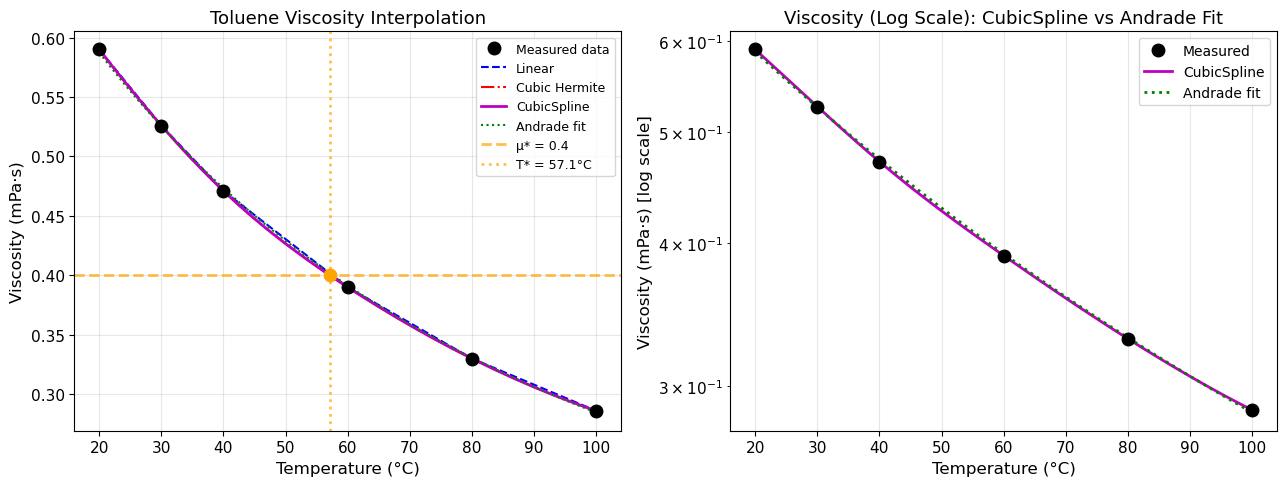

✓ 圖片已儲存


In [48]:
# ============================================================
# 化工案例一：液體黏度隨溫度的插值與逆向插值
# ============================================================
# 甲苯 (Toluene) 動黏度量測數據 (mPa·s)
T_mu  = np.array([20.0, 30.0, 40.0, 60.0, 80.0, 100.0])   # 溫度 (°C)
mu_data = np.array([0.590, 0.526, 0.471, 0.390, 0.330, 0.286])  # 黏度 (mPa·s)

# 留出 T=50°C 作驗證點（真實值約 0.429 mPa·s）
T_test_pts  = np.array([50.0, 70.0])

# ----- 建立各插值函數 -----
f_lin  = interp1d(T_mu, mu_data, kind='linear')
f_cub  = interp1d(T_mu, mu_data, kind='cubic')
f_cs   = CubicSpline(T_mu, mu_data)

# ----- 插值結果比較 -----
T_fine = np.linspace(20, 100, 300)
print("插值結果比較:")
print(f"{'T(°C)':>8}  {'Linear':>8}  {'Cubic':>8}  {'CubicSpline':>12}")
for T_q in T_test_pts:
    print(f"{T_q:>8.1f}  {f_lin(T_q):>8.4f}  {f_cub(T_q):>8.4f}  {f_cs(T_q):>12.4f}")

# ----- 逆向插值：給定目標黏度 0.40 mPa·s，求對應溫度 -----
mu_target = 0.40
T_star = brentq(lambda T: f_cs(T) - mu_target, T_mu[0], T_mu[-1])
print(f"\n逆向插值: 目標黏度 {mu_target} mPa·s 對應溫度 T* = {T_star:.2f} °C")
print(f"  驗證: f_cs({T_star:.2f}) = {f_cs(T_star):.6f} mPa·s")

# ----- 溫度依賴性的 Andrade 方程式擬合 ---
# ln(μ) = A + B/T  (T in K)
T_K = T_mu + 273.15
ln_mu = np.log(mu_data)
coeffs = np.polyfit(1 / T_K, ln_mu, 1)  # 線性回歸 ln(μ) vs 1/T
print(f"\nAndrade 方程式擬合: ln(μ) = {coeffs[0]:.1f}/T + {coeffs[1]:.3f}")
print(f"  (A = {coeffs[1]:.3f}, B = {coeffs[0]:.1f} K)")

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(T_mu, mu_data, 'ko', markersize=9, zorder=5, label='Measured data')
ax.plot(T_fine, f_lin(T_fine),  'b--', lw=1.5, label='Linear')
ax.plot(T_fine, f_cub(T_fine),  'r-.',  lw=1.5, label='Cubic Hermite')
ax.plot(T_fine, f_cs(T_fine),   'm-',  lw=2.0, label='CubicSpline')
T_fine_K = T_fine + 273.15
mu_andrade = np.exp(np.polyval(coeffs, 1/T_fine_K))
ax.plot(T_fine, mu_andrade, 'g:', lw=1.5, label='Andrade fit')
ax.axhline(y=mu_target, color='orange', ls='--', alpha=0.7, label=f'μ* = {mu_target}')
ax.axvline(x=T_star,    color='orange', ls=':',  alpha=0.7, label=f'T* = {T_star:.1f}°C')
ax.scatter([T_star], [mu_target], c='orange', s=80, zorder=6)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Viscosity (mPa·s)')
ax.set_title('Toluene Viscosity Interpolation')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.semilogy(T_mu, mu_data, 'ko', markersize=9, zorder=5, label='Measured')
ax2.plot(T_fine, f_cs(T_fine), 'm-', lw=2, label='CubicSpline')
ax2.plot(T_fine, mu_andrade, 'g:', lw=2, label='Andrade fit')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Viscosity (mPa·s) [log scale]')
ax2.set_title('Viscosity (Log Scale): CubicSpline vs Andrade Fit')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec11_viscosity_interpolation.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 12. 化工應用二：批次反應速率推斷 (Reaction Rate Inference by Differentiation)

### 問題說明

批次反應 $A + B \rightarrow R$，已知不同時刻的產物 $R$ 濃度量測值 $C_R(t)$。
目標：由 $C_R(t)$ 數據推斷反應速率及動力學參數。

### 分析步驟

1. 由 $C_R(t)$ 取微分得反應速率 $r_R = dC_R/dt$
2. 若反應為冪次速率定律：$r_R = k \cdot C_A^N$，其中 $C_A = C_{A0} - C_R$
3. 取對數：$\ln r_R = \ln k + N \cdot \ln C_A$
4. 以 $\ln r_R$ 對 $\ln C_A$ 線性回歸，求斜率 $N$（反應階數）和截距 $\ln k$

線性回歸結果:
  反應階數 N = 1.998  (真實值: 2.0)
  速率常數 k = 0.0485 L/(mol·min)  (真實值: 0.05)

取整數階數 N=2:
  重新估計 k = 0.0486 L/(mol·min)  (真實值: 0.05)


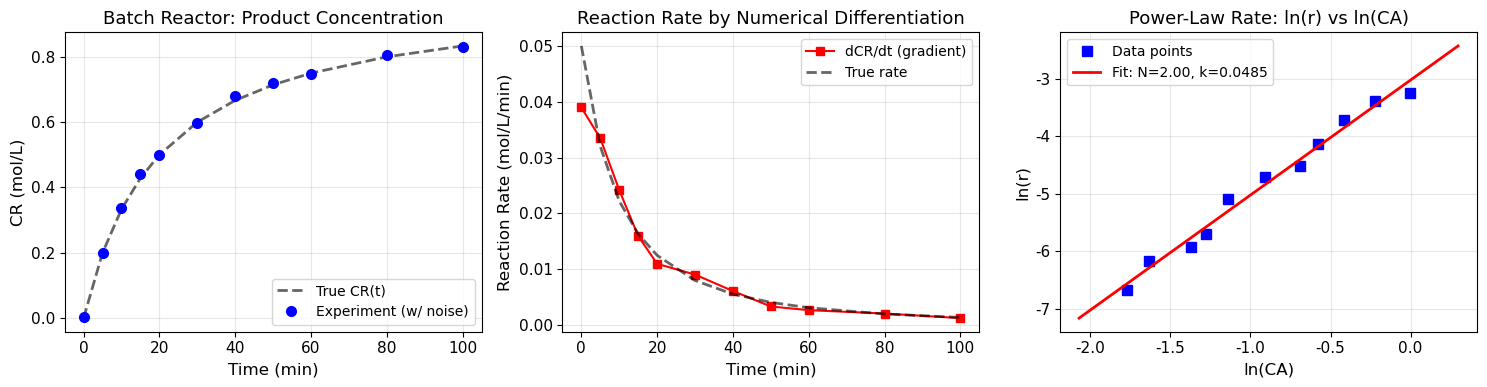

✓ 圖片已儲存


In [49]:
# ============================================================
# 化工案例二：批次反應 A+B→R  反應速率與動力學參數推斷
# ============================================================
# 模擬實驗數據：二次反應 r = k*CA^2, k=0.05 L/(mol·min), CA0=1.0 mol/L
# 數值解 ODE 生成 "實驗數據"
np.random.seed(42)

t_exp = np.array([0, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100])  # min
CA0   = 1.0   # mol/L
k_true = 0.05  # L/(mol·min)

# 解析解 1/(CA) = 1/CA0 + k*t
CA_true  = CA0 / (1 + k_true * t_exp * CA0)
CR_true  = CA0 - CA_true

# 加入測量噪音
noise = np.random.normal(0, 0.008, len(t_exp))
CR_exp = np.clip(CR_true + noise, 0, CA0)
CA_exp = CA0 - CR_exp

# ----- 步驟 1: 計算反應速率 r = dCR/dt -----
r_grad = np.gradient(CR_exp, t_exp)  # 中間差分
r_grad = np.clip(r_grad, 1e-6, None)  # 避免負值或零

# ----- 步驟 2: 對數線性化 -----
# 排除邊界點（可能誤差較大）
idx = (r_grad > 1e-5) & (CA_exp > 0.05)
ln_r  = np.log(r_grad[idx])
ln_CA = np.log(CA_exp[idx])

# ----- 步驟 3: 線性回歸 -----
coeffs_rxn = np.polyfit(ln_CA, ln_r, 1)
N_fit = coeffs_rxn[0]
k_fit = np.exp(coeffs_rxn[1])
print(f"線性回歸結果:")
print(f"  反應階數 N = {N_fit:.3f}  (真實值: 2.0)")
print(f"  速率常數 k = {k_fit:.4f} L/(mol·min)  (真實值: {k_true})")

# 取整數反應階數
N_int = round(N_fit)
k_refit = np.exp(np.mean(ln_r - N_int * ln_CA))
print(f"\n取整數階數 N={N_int}:")
print(f"  重新估計 k = {k_refit:.4f} L/(mol·min)  (真實值: {k_true})")

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(t_exp, CR_true, 'k--', lw=2, alpha=0.6, label='True CR(t)')
ax.plot(t_exp, CR_exp, 'bo', markersize=7, label='Experiment (w/ noise)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('CR (mol/L)')
ax.set_title('Batch Reactor: Product Concentration')
ax.legend()

ax2 = axes[1]
ax2.plot(t_exp, r_grad, 'rs-', lw=1.5, markersize=6, label='dCR/dt (gradient)')
r_true = k_true * CA_true**2
ax2.plot(t_exp, r_true, 'k--', lw=2, alpha=0.6, label='True rate')
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('Reaction Rate (mol/L/min)')
ax2.set_title('Reaction Rate by Numerical Differentiation')
ax2.legend()

ax3 = axes[2]
ln_CA_plot = np.linspace(ln_CA.min() - 0.3, ln_CA.max() + 0.3, 50)
ax3.plot(ln_CA, ln_r, 'bs', markersize=7, label='Data points')
ax3.plot(ln_CA_plot, np.polyval(coeffs_rxn, ln_CA_plot), 'r-', lw=2,
         label=f'Fit: N={N_fit:.2f}, k={k_fit:.4f}')
ax3.set_xlabel('ln(CA)')
ax3.set_ylabel('ln(r)')
ax3.set_title('Power-Law Rate: ln(r) vs ln(CA)')
ax3.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec12_reaction_rate_differentiation.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 13. 化工應用三：滯留時間分布 RTD 分析 (RTD Analysis)

### 問題說明

脈衝追蹤劑實驗 (Pulse Tracer Test) 中，測量出口濃度信號 $C(t)$。
計算 RTD 函數 $E(t)$ 及流動特性參數。

### 計算步驟

1. 正規化濃度信號得 RTD 函數：

$$E(t) = \frac{C(t)}{\int_0^\infty C(t)\,dt}$$

2. 計算平均滯留時間：

$$\bar{t} = \int_0^\infty t \cdot E(t)\,dt$$

3. 計算方差（二次矩）：

$$\sigma^2 = \int_0^\infty (t - \bar{t})^2 \cdot E(t)\,dt$$

4. 無因次方差 $\sigma_\theta^2 = \sigma^2 / \bar{t}^2$：
   - 理想平推流 (PFR)：$\sigma_\theta^2 = 0$
   - 理想混合流 (CSTR)：$\sigma_\theta^2 = 1$
   - 實際反應器：$0 < \sigma_\theta^2 < 1$

∫C(t)dt = 1.0329  (正規化後 ∫E(t)dt = 1.000000)
平均滯留時間 t̄ = 9.900 min  (名義值: 10.0 min)
方差 σ² = 99.977 min²
無因次方差 σθ² = 1.0201  (CSTR理論值: 1.0)


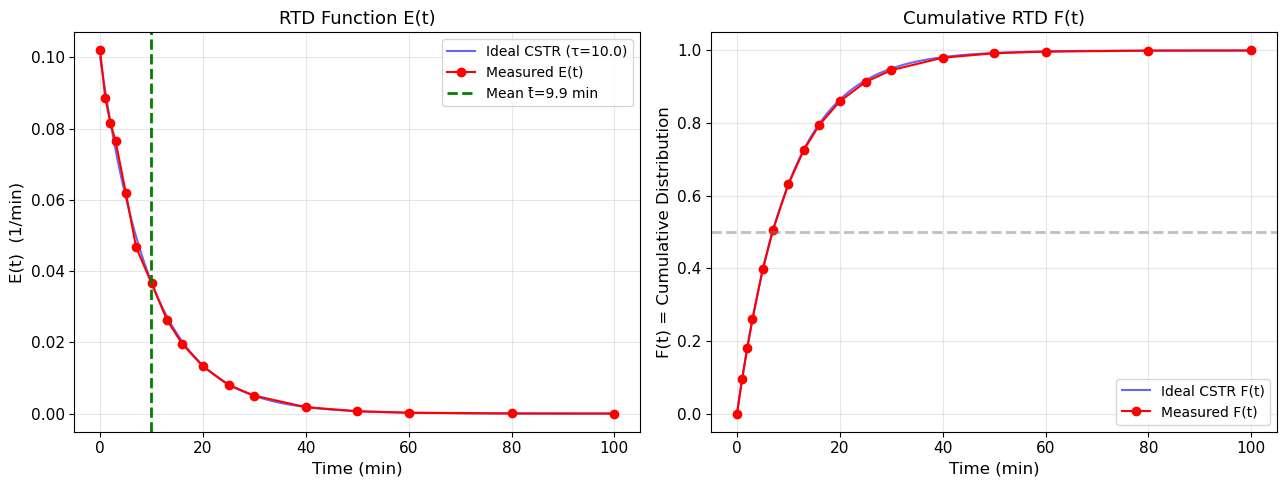

✓ 圖片已儲存


In [50]:
# ============================================================
# 化工案例三：脈衝追蹤劑 RTD 分析
# ============================================================
# 模擬追蹤劑實驗數據（非等間距時間點）
# CSTR (tau=10 min): E(t) = (1/tau)*exp(-t/tau)
# 使用比例噪聲（3% 相對誤差，更符合實際濃度計量測特性）

tau_rtd = 10.0  # 名義滯留時間 (min)

# 非等間距時間採樣（模擬實際量測）
t_rtd = np.array([0, 1, 2, 3, 5, 7, 10, 13, 16, 20, 25, 30, 40, 50, 60, 80, 100])
np.random.seed(0)
noise_pct = 0.03  # 3% 相對噪聲（比例噪聲，適用於全量測範圍）
C_true = (1/tau_rtd) * np.exp(-t_rtd / tau_rtd)
C_meas = C_true * (1 + np.random.normal(0, noise_pct, len(t_rtd)))
C_meas = np.clip(C_meas, 0, None)

# ----- 步驟 1: 計算 ∫C(t)dt 進行正規化 -----
integral_C = trapezoid(C_meas, t_rtd)
E_t = C_meas / integral_C
print(f"∫C(t)dt = {integral_C:.4f}  (正規化後 ∫E(t)dt = {trapezoid(E_t, t_rtd):.6f})")

# ----- 步驟 2: 計算平均滯留時間 -----
t_mean = trapezoid(t_rtd * E_t, t_rtd)
print(f"平均滯留時間 t̄ = {t_mean:.3f} min  (名義值: {tau_rtd} min)")

# ----- 步驟 3: 計算方差 -----
sigma2 = trapezoid((t_rtd - t_mean)**2 * E_t, t_rtd)
sigma_theta2 = sigma2 / t_mean**2
print(f"方差 σ² = {sigma2:.3f} min²")
print(f"無因次方差 σθ² = {sigma_theta2:.4f}  (CSTR理論值: 1.0)")

# ----- 步驟 4: 計算累積分布 F(t) -----
F_t = np.array([trapezoid(E_t[:i+1], t_rtd[:i+1]) for i in range(len(t_rtd))])

# ----- 比較：理想 CSTR -----
t_fine = np.linspace(0, 100, 300)
E_cstr = (1/tau_rtd) * np.exp(-t_fine / tau_rtd)
F_cstr = 1 - np.exp(-t_fine / tau_rtd)

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(t_fine, E_cstr, 'b-', lw=1.5, alpha=0.6, label=f'Ideal CSTR (τ={tau_rtd})')
ax.plot(t_rtd, E_t, 'ro-', markersize=6, lw=1.5, label='Measured E(t)')
ax.axvline(x=t_mean, color='g', ls='--', lw=2, label=f'Mean t̄={t_mean:.1f} min')
ax.set_xlabel('Time (min)')
ax.set_ylabel('E(t)  (1/min)')
ax.set_title('RTD Function E(t)')
ax.legend()

ax2 = axes[1]
ax2.plot(t_fine, F_cstr, 'b-', lw=1.5, alpha=0.6, label='Ideal CSTR F(t)')
ax2.plot(t_rtd, F_t, 'ro-', markersize=6, lw=1.5, label='Measured F(t)')
ax2.axhline(y=0.5, color='gray', ls='--', alpha=0.5)
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('F(t) = Cumulative Distribution')
ax2.set_title('Cumulative RTD F(t)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec13_rtd_analysis.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 14. 化工應用四：填充塔吸收器 (NOG 計算)

### 問題背景
填充塔吸收計算中，傳質單元數 (Number of Overall Gas-phase Transfer Units, $N_{OG}$) 定義為：

$$
N_{OG} = \int_{y_2}^{y_1} \frac{dy}{y - y^*}
$$

其中：
- $y$ 為氣相中溶質莫耳分率（從底部 $y_1$ 到頂部 $y_2$，$y_1 > y_2$）
- $y^*$ 為與液相平衡的氣相莫耳分率（由平衡曲線決定）

### 求解流程
1. **建立平衡線**：由實驗數據 $(x, y^*)$ 擬合平衡曲線
2. **建立操作線**：物料平衡決定 $y = \frac{L}{G}(x - x_2) + y_2$
3. **建立積分函數**：對每個 $y$ 值，由操作線求 $x$，由平衡線求 $y^*$，計算 $1/(y-y^*)$
4. **數值積分**：使用 `scipy.integrate.quad()` 計算 $N_{OG}$
5. **塔高計算**：$H = N_{OG} \cdot H_{OG}$（$H_{OG}$ 為傳質單元高度）

| 參數 | 值 |
|-----|-----|
| 進口氣體 $y_1$ | 0.040 (4 mol%) |
| 出口氣體 $y_2$ | 0.004 (0.4 mol%) |
| 進口液體 $x_2$ | 0 (純溶劑) |
| 傳質單元高度 $H_{OG}$ | 0.6 m |

最小液氣比 (L/G)min = 0.7802
  (x1 出口液相最大平衡值 x1_max = 0.0461)
L/G = 0.936 (1.2×min): N_OG = 6.901, 塔高 H = 4.14 m
L/G = 1.170 (1.5×min): N_OG = 4.572, 塔高 H = 2.74 m
L/G = 1.560 (2.0×min): N_OG = 3.553, 塔高 H = 2.13 m
L/G = 1.950 (2.5×min): N_OG = 3.164, 塔高 H = 1.90 m
L/G = 2.340 (3.0×min): N_OG = 2.961, 塔高 H = 1.78 m


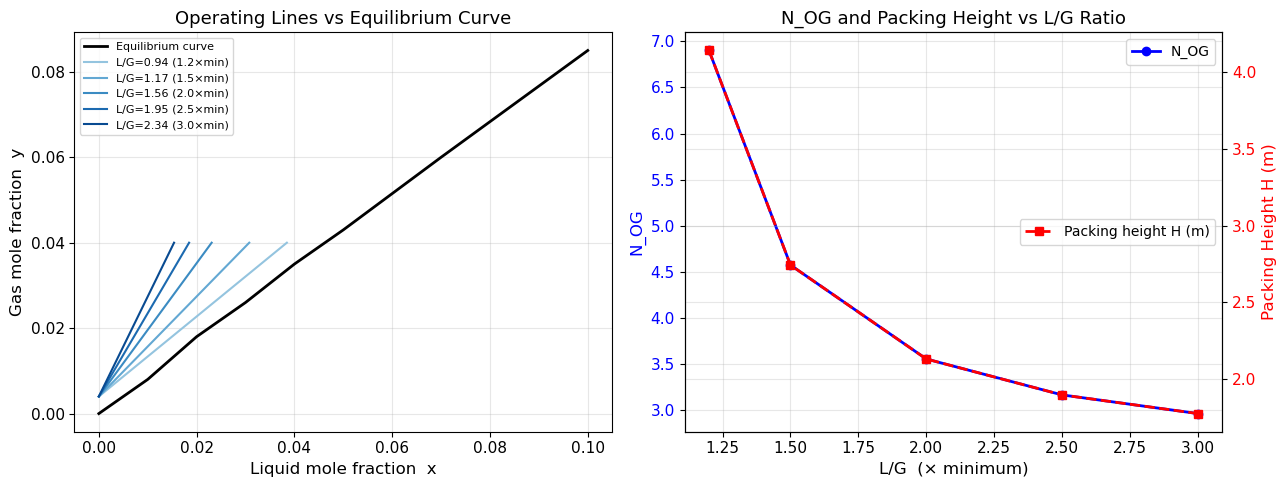

✓ 圖片已儲存


In [51]:
# ============================================================
# 化工案例四：填充塔 NOG 計算
# ============================================================
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import quad

# ----- 平衡數據 (mol fraction) -----
x_eq = np.array([0.000, 0.005, 0.010, 0.020, 0.030, 0.040, 0.050, 0.070, 0.100])
y_eq = np.array([0.000, 0.004, 0.008, 0.018, 0.026, 0.035, 0.043, 0.060, 0.085])

# 用 CubicSpline 擬合平衡曲線 y* = f(x)
cs_eq = CubicSpline(x_eq, y_eq)

# ----- 操作條件 -----
y1 = 0.040   # 進口氣體 (塔底)
y2 = 0.004   # 出口氣體 (塔頂)
x2 = 0.000   # 進口淨溶劑 (塔頂)
H_OG = 0.6   # m per transfer unit

# 不同 L/G 比例
LG_ratios = [1.2, 1.5, 2.0, 2.5, 3.0]  # L/G 的最小值倍數

# 當 L/G → min 時 (使用數值求反) 求出口液體 x1_max
# 操作線：y = (L/G)*(x - x2) + y2  → x = (y - y2)*(G/L) + x2
# 最小 L/G：出口液相達平衡 y1 = y*(x1_max)
x1_max_func = lambda x: cs_eq(x) - y1
x1_max = brentq(x1_max_func, 0.01, 0.10)
LG_min = (y1 - y2) / (x1_max - x2)
print(f"最小液氣比 (L/G)min = {LG_min:.4f}")
print(f"  (x1 出口液相最大平衡值 x1_max = {x1_max:.4f})")

results = []
for ratio in LG_ratios:
    LG = ratio * LG_min
    x1 = (y1 - y2) / LG + x2   # 出口液相莫耳分率

    # 積分函數：對 y 積分
    def integrand(y):
        x_op = (y - y2) / LG + x2   # 操作線上的 x
        y_star = cs_eq(x_op)
        driving = y - y_star
        if driving <= 1e-10:
            return 1e6
        return 1.0 / driving

    N_OG, err = quad(integrand, y2, y1)
    H_packed = N_OG * H_OG
    results.append({'LG': LG, 'ratio': ratio, 'N_OG': N_OG, 'H': H_packed, 'x1': x1})
    print(f"L/G = {LG:.3f} ({ratio}×min): N_OG = {N_OG:.3f}, 塔高 H = {H_packed:.2f} m")

# ----- 繪圖 -----
y_plot = np.linspace(y2, y1, 200)
x_plot = np.linspace(x2, x1_max*1.2, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(x_eq, y_eq, 'k-', lw=2, label='Equilibrium curve')
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(LG_ratios)))
for res, c in zip(results, colors):
    LG_r = res['LG']
    x1_r = res['x1']
    ax1.plot([x2, x1_r], [y2, y1], '-', color=c, lw=1.5,
             label=f"L/G={LG_r:.2f} ({res['ratio']}×min)")
ax1.set_xlabel('Liquid mole fraction  x')
ax1.set_ylabel('Gas mole fraction  y')
ax1.set_title('Operating Lines vs Equilibrium Curve')
ax1.legend(fontsize=8)

ax2 = axes[1]
ratios_arr = [r['ratio'] for r in results]
NOG_arr    = [r['N_OG']  for r in results]
H_arr      = [r['H']     for r in results]
ax2.plot(ratios_arr, NOG_arr, 'b-o', label='N_OG')
ax2.set_xlabel('L/G  (× minimum)')
ax2.set_ylabel('N_OG', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2b = ax2.twinx()
ax2b.plot(ratios_arr, H_arr, 'r--s', label='Packing height H (m)')
ax2b.set_ylabel('Packing Height H (m)', color='r')
ax2b.tick_params(axis='y', labelcolor='r')
ax2.set_title('N_OG and Packing Height vs L/G Ratio')
ax2.legend(loc='upper right')
ax2b.legend(loc='center right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec14_absorber_ntu.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
## 15. 程式設計最佳實踐

### 15.1 插值方法選擇指南

| 情境 | 建議方法 | 原因 |
|------|---------|------|
| 少量數據點，需平滑曲線 | `CubicSpline` | C² 連續，無 Runge 震盪 |
| 數據多且均勻分布 | `interp1d(kind='linear')` | 快速佔記憶體少 |
| 需處理外插 | `interp1d` + `fill_value='extrapolate'` | 注意誤差放大 |
| 二維規則網格 | `RegularGridInterpolator` | 速度快，向量化支援好 |
| 二維散點數據 | `griddata` | 自動 Delaunay 三角剖分 |

### 15.2 數值微分注意事項

| 問題 | 解決方案 |
|------|---------|
| 步長過小導致捨入誤差 | 選擇合理步長：前向差分 $h \approx \sqrt{\epsilon_{\text{mach}}} \approx 10^{-8}$；中心差分 $h \approx \epsilon_{\text{mach}}^{1/3} \approx 10^{-5}$ |
| 步長過大導致截斷誤差 | 使用中心差分，誤差 $O(h^2)$ 優於 $O(h)$ |
| 數據有雜訊 | 先平滑（移動平均/Savitzky-Golay），再微分 |
| 非均等間距數據 | 使用 `np.gradient` 自動處理，或先插值再微分 |

### 15.3 數值積分選擇指南

| 輸入類型 | 建議函數 | 特點 |
|---------|---------|------|
| 離散數據點（等間距）| `trapezoid` → `simpson` | 簡單且穩定 |
| 離散數據點（非等間距）| `trapezoid` | 自動處理 |
| 解析函數（有限範圍）| `quad` | 自適應，精度高 |
| 解析函數（無限範圍）| `quad` + 特殊端點 | 支援 `np.inf` |
| 二維積分 | `dblquad` / `nquad` | 注意積分順序 |

### 15.4 常見錯誤警示

```python
# ❌ 錯誤：外插超出範圍且未設保護
cs = CubicSpline(x_data, y_data)
y_extrap = cs(x_far_outside)   # 可能爆炸到極大值或極小值

# ✅ 正確：先檢查範圍
if x_query < x_data.min() or x_query > x_data.max():
    print(f"警告：{x_query} 超出插值範圍 [{x_data.min()}, {x_data.max()}]")

# ❌ 錯誤：誤以為積分誤差絕對可忽略
result, error = quad(f, a, b)
# ✅ 正確：驗證相對誤差
print(f"積分 = {result:.6f}, 相對誤差 ≈ {error/abs(result):.2e}")
```

∫exp(-x²)dx over [-10,10]: 1.7724538509  |  誤差估計: 3.70e-13  |  與√π差: 2.22e-16
∫exp(-x²)dx over [-50,50]: 1.7724538509  |  誤差估計: 1.98e-10  |  與√π差: 2.22e-16
∫exp(-x²)dx over (-∞,∞): 1.7724538509  |  誤差估計: 1.42e-08  |  與√π差: 0.00e+00


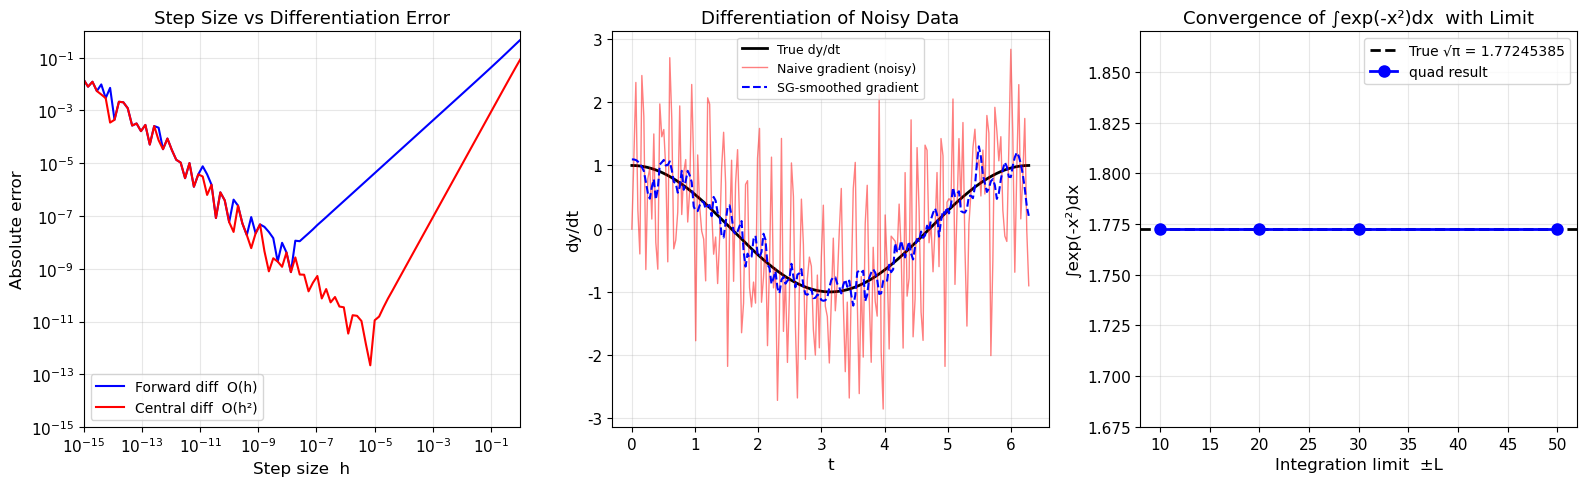

✓ 圖片已儲存

✅  Unit08 Notebook 全部完成！


In [52]:
# ============================================================
# 15. 最佳實踐示範：步長選擇與誤差分析
# ============================================================
from scipy.signal import savgol_filter

# ----- (A) 數值微分步長最佳化 -----
f_true  = lambda x: np.sin(x)
df_true = lambda x: np.cos(x)

x0 = 1.0
h_values = np.logspace(-15, 0, 100)

err_forward  = []
err_central  = []
for h in h_values:
    fwd = (f_true(x0 + h) - f_true(x0)) / h
    cnt = (f_true(x0 + h) - f_true(x0 - h)) / (2*h)
    err_forward.append(abs(fwd - df_true(x0)))
    err_central.append(abs(cnt - df_true(x0)))

# ----- (B) 雜訊數據的微分策略 -----
np.random.seed(42)
t_noisy = np.linspace(0, 2*np.pi, 200)
y_clean = np.sin(t_noisy)
y_noisy = y_clean + np.random.normal(0, 0.05, len(t_noisy))

dy_naive   = np.gradient(y_noisy, t_noisy)        # 直接微分（雜訊放大）
y_smooth   = savgol_filter(y_noisy, window_length=15, polyorder=3)
dy_smooth  = np.gradient(y_smooth, t_noisy)        # 先平滑再微分
dy_true    = np.cos(t_noisy)                       # 理論值

# ----- (C) 積分誤差驗證 -----
from scipy.integrate import quad
f_int = lambda x: np.exp(-x**2)
I_true = np.sqrt(np.pi)  # ∫_{-∞}^{∞} exp(-x²) dx = √π

for a_lim, b_lim, label in [(-10, 10, '[-10,10]'), (-50, 50, '[-50,50]'), (-np.inf, np.inf, '(-∞,∞)')]:
    val, err = quad(f_int, a_lim, b_lim)
    print(f"∫exp(-x²)dx over {label}: {val:.10f}  |  誤差估計: {err:.2e}  |  與√π差: {abs(val-I_true):.2e}")

# ----- 繪圖 -----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.loglog(h_values, err_forward, 'b-', lw=1.5, label='Forward diff  O(h)')
ax.loglog(h_values, err_central, 'r-', lw=1.5, label='Central diff  O(h²)')
ax.set_xlabel('Step size  h')
ax.set_ylabel('Absolute error')
ax.set_title('Step Size vs Differentiation Error')
ax.legend()
ax.set_xlim([1e-15, 1])
ax.set_ylim([1e-15, 1])

ax2 = axes[1]
ax2.plot(t_noisy, dy_true,   'k-',  lw=2,   label='True dy/dt')
ax2.plot(t_noisy, dy_naive,  'r-',  lw=1,   alpha=0.5, label='Naive gradient (noisy)')
ax2.plot(t_noisy, dy_smooth, 'b--', lw=1.5, label='SG-smoothed gradient')
ax2.set_xlabel('t')
ax2.set_ylabel('dy/dt')
ax2.set_title('Differentiation of Noisy Data')
ax2.legend(fontsize=9)

ax3 = axes[2]
limits   = [10, 20, 30, 50]
int_vals = [quad(f_int, -L, L)[0] for L in limits]
ax3.axhline(y=np.sqrt(np.pi), color='k', ls='--', label=f'True √π = {np.sqrt(np.pi):.8f}')
ax3.plot(limits, int_vals, 'b-o', markersize=8, label='quad result')
ax3.set_xlabel('Integration limit  ±L')
ax3.set_ylabel('∫exp(-x²)dx')
ax3.set_title('Convergence of ∫exp(-x²)dx  with Limit')
ax3.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sec15_best_practices.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")
print("\n✅  Unit08 Notebook 全部完成！")